In [72]:
import os
import copy
import numpy as np
import scipy
import pandas
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc

# Heart disease classification

We study the [Heart disease](https://www.kaggle.com/datasets/bharath011/heart-disease-classification-dataset) dataset. The goal is to classify correctly the presence of a disease basen on a set of features.

In [73]:
df = pandas.read_csv("data/heart_disease_classification.csv")
df

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


**Question 1**

Build the dataframe of features `X` and the series of targets `y`. Split them into a train set and a test set.

In [74]:
n_splits = 20    # number of splits when we perform cross-validation

In [75]:
df.columns

Index(['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose',
       'kcm', 'troponin', 'class'],
      dtype='object')

In [76]:
target_name = "class"
features = list(df.columns)
features.remove(target_name)

X = df[features]
y = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

**Question 2**

Perform logistic regression with `sklearn.linear_model.LogisticRegression` and compute the cross-validation score (on the train set).

If the numerical method fails to converge, one can increase the attribute `max_iter` of `LogisticRegression`.

In [77]:
lrg = LogisticRegression(max_iter = 1000)
lst_scores = cross_val_score(lrg, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

0.7943396226415095


**Question 3**

Train the model on the train set. Check the `classes_` and the `coef_` attributes of the model. What are the variables that are positively correlated with the `positive` class?

In [78]:
lrg.fit(X_train, y_train)
print(lrg.classes_)
print(lrg.coef_)

['negative' 'positive']
[[ 5.01881372e-02  4.94267992e-01 -1.59959186e-04 -2.44943477e-03
  -3.20423362e-03 -1.03694454e-04  3.51103838e-01  3.25083636e+00]]


When `positive` is at index 1 in `classes_`, the variables associated with it are those whose coefficients are positive: age, gender, impluse, pressurelow, kcm, troponin. 

If `positive` is at index 0 in `classes_`, we retain the variables with negative coefficients (which are the same as above).

**Question 4**

Perform the same training with a Linear Discriminant Analysis (LDA), a Quadratic Discriminant Analysis (QDA), Gaussian Naive Bayes (GNB) and the k-nearest neighbors (kNN) (with $k = 5$). Compare the cross-validation losses.

Visualize it on the same `boxplot` of `matplotlib` and show the variability of the validation losses across the splits. 

Comment the results.

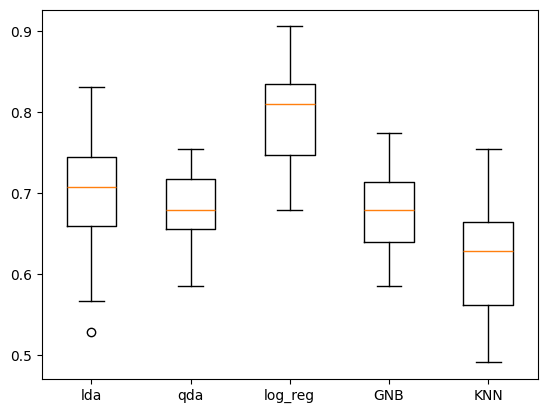

In [79]:
lst_methods = [("lda", LinearDiscriminantAnalysis()),
              ("qda", QuadraticDiscriminantAnalysis(reg_param = 1e-3)),
              ("log_reg", LogisticRegression(max_iter = 1000)),
              ("GNB", GaussianNB()),
              ("KNN", KNeighborsClassifier(n_neighbors = 5))]

lst_labels = []
lst_boxplots = []
for name, method in lst_methods:
    lst_boxplots.append(np.array(cross_val_score(method, X_train, y_train, cv = n_splits)))
    lst_labels.append(name)
    
plt.boxplot(lst_boxplots)
plt.xticks(list(range(1, len(lst_labels) + 1)), lst_labels)
plt.show()

The logistic regression is consistently better than the other methods.

**Question 5**

For each of the 5 methods, train it on the train set and show the test score. Conclude.

In [80]:
lst_labels = []
lst_boxplots = []
for name, method in lst_methods:
    method.fit(X_train, y_train)
    s = method.score(X_test, y_test)
    print(f"Test score of {name}: \t{s:.3f}")

Test score of lda: 	0.697
Test score of qda: 	0.659
Test score of log_reg: 	0.814
Test score of GNB: 	0.655
Test score of KNN: 	0.595


The logistic regression is far better than the other methods on this task.

**Question 6**

Plot the table of results: train score, average score of cross-validation and test score.

In [81]:
def compute_train(method, X_train, y_train):
    method.fit(X_train, y_train)
    return method.score(X_train, y_train)

def compute_CV(method, X_train, y_train):
    return np.mean(np.array(cross_val_score(method, X_train, y_train, cv = n_splits)))

def compute_test(method, X_train, y_train, X_test, y_test):
    method.fit(X_train, y_train)
    return method.score(X_test, y_test)

lst_method_names = [name for name, _ in lst_methods]
lst_metrics = ["train score", "CV score", "test score"]

tbl_results = pandas.DataFrame(index = lst_method_names, columns = lst_metrics)

for meth_name, method in lst_methods:
    tbl_results.at[meth_name, "train score"] = compute_train(method, X_train, y_train)
    tbl_results.at[meth_name, "CV score"] = compute_CV(method, X_train, y_train)
    tbl_results.at[meth_name, "test score"] = compute_test(method, X_train, y_train, X_test, y_test)

In [82]:
tbl_results

,train score,CV score,test score
lda,0.705213,0.70049,0.69697
qda,0.679621,0.677739,0.659091
log_reg,0.797156,0.79434,0.814394
GNB,0.672986,0.67578,0.655303
KNN,0.758294,0.615385,0.594697


**Question 7**

Check if the classes were actually balanced.

In [83]:
df["class"].value_counts()

class
positive    810
negative    509
Name: count, dtype: int64

Answer: not really, there are almost 40 % less data points labeled as "negative" than ones labeled as "positive". So, all the above computation may biased.

**Question 8**

Compute the precision and recall scores. What do we observe? Use `sklearn.metrics.precision_recall_fscore_support`.

In [84]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)

In [85]:
from sklearn.metrics import precision_recall_fscore_support
method = LogisticRegression(max_iter=1000)
method.fit(X_tr,y_tr)
y_pred = method.predict(X_val) ##predict y 
precision_recall_fscore_support(y_val,y_pred,average="binary",pos_label="positive")

## We can get 4 values : 
# precision — 预测为正的里面，真正是正的比例（不乱报警）
# recall — 真正是正的里面，被预测出来的比例（不漏报）
# fscore — precision和recall的综合，一个数概括模型好不好
# support — 测试集中正类的样本数量（只是个参考数字，不是性能指标）

(0.8120300751879699, 0.8503937007874016, 0.8307692307692308, None)

We observe that the precision score is larger than the recall score. If we want to be sure that the largest number of positive cases are detected (i.e., the largest number of patients suffering from a heart disease), we want to increase the recall score.

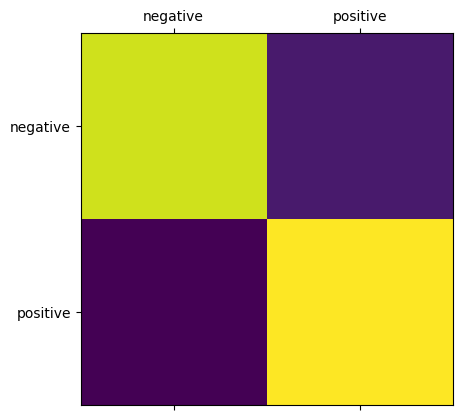

In [86]:
confusion = confusion_matrix(y_tr, method.predict(X_tr))

plt.matshow((confusion.T / confusion.sum(1)).T)
plt.xticks(list(range(2)), method.classes_)
plt.yticks(list(range(2)), method.classes_)
plt.show()

**Question 9**

Compute the ROC curve and the AUC. One can use the `decision_function` method of a model and `sklearn.metrics.roc_curve`.

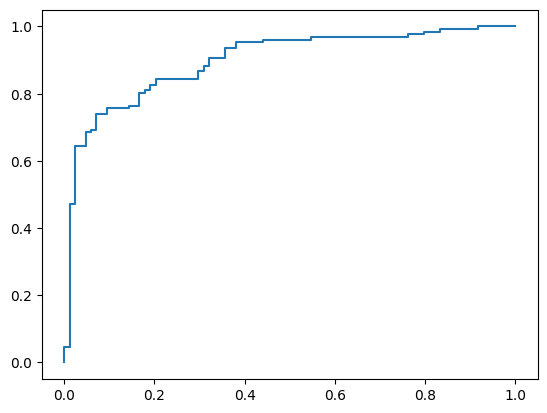

In [87]:
method = LogisticRegression(max_iter = 1000)
method.fit(X_tr, y_tr)

y_val_scores = method.decision_function(X_val)

false_positive, true_positive, _ = roc_curve(y_val, y_val_scores, pos_label = "positive")

plt.plot(false_positive, true_positive)

In [88]:
auc(false_positive, true_positive)

np.float64(0.8977315335583053)

**Question 10**

Take the models LDA, QDA, logistic regression and GaussianNB, plot their ROC and compute their AUC.

AUC of lda: 	0.669
AUC of qda: 	0.924
AUC of log_reg: 	0.898
AUC of GNB: 	0.947


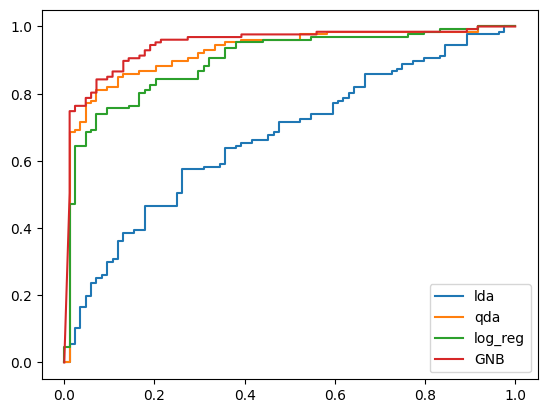

In [89]:
lst_auc = []
for name, method in lst_methods[:-1]:
    method.fit(X_tr, y_tr)
    if name == "GNB":
        y_val_scores = method.predict_proba(X_val)[:, 1]
    else:
        y_val_scores = method.decision_function(X_val)
    false_positive, true_positive, _ = roc_curve(y_val, y_val_scores, pos_label = "positive")
    plt.plot(false_positive, true_positive, label = name)
    auc_ = auc(false_positive, true_positive)
    lst_auc.append((name, auc_))
    
    print(f"AUC of {name}: \t{auc_:.3f}")

plt.legend()

# Stars classification (NASA dataset)

We study the [NASA stars classification dataset](https://www.kaggle.com/datasets/brsdincer/star-type-classification). The goal is to classify the stars based on observations and measures (temperature, radius, luminosity...).

In [90]:
df = pandas.read_csv("stars_nasa_classification.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'stars_nasa_classification.csv'

**Question 1**

Build the dataframe of *numerical* features `X` and the series of targets `y`. Split them into a train set and a test set.

In [ ]:
n_splits = 20

In [ ]:
var_names = ["Temperature", "L", "R", "A_M"]
target_name = "Type"

X = df[var_names]
y = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

**Question 2**

Perform a LDA, a QDA, a logistic regression, GNB and kNN ($k = 5$) and compute the cross-validation losses.

In [ ]:
lda = LinearDiscriminantAnalysis()
lst_scores = cross_val_score(lda, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
qda = QuadraticDiscriminantAnalysis(reg_param = 1e-3)
lst_scores = cross_val_score(qda, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
lrg = LogisticRegression(max_iter = 1000)
lst_scores = cross_val_score(lrg, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
gnb = GaussianNB()
lst_scores = cross_val_score(gnb, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 5)
lst_scores = cross_val_score(knn, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

**Question 3**

Some methods tend to perform poorly. Propose a pre-processing of the data that is likely to solve this problem.

One can plot the distribution of each variable.

In [ ]:
fig, ax = plt.subplots(1, len(var_names))

fig.set_size_inches(12, 2.2)

for i, vname in enumerate(var_names):
    ax[i].hist(X_train[vname])
    ax[i].set_title(vname)

The variables "Temperature", "R" and "L" seem to span several orders of magnitudes. Besides, they are always positive. So it is likely that we should take the log of them before using them.

In [ ]:
fig, ax = plt.subplots(2, len(var_names))

fig.set_size_inches(12, 5)

for i, vname in enumerate(var_names):
    ax[0, i].hist(X_train[vname])
    ax[0, i].set_title(vname)
    ax[1, i].hist(np.log(X_train[vname].to_numpy()))

**Question 4**

Transform the variables and perform again the various classification methods.

Comment the results.

In [ ]:
vnames_logs = ["Temperature", "R", "L"]
vnames_lins = list(set(var_names) - set(vnames_logs))

Xl_train = X_train.copy(deep = True)
Xl_test = X_test.copy(deep = True)

for name_log in vnames_logs:
    Xl_train[name_log] = X_train[name_log].apply(lambda x: np.log(x))
    
for name_log in vnames_logs:
    Xl_test[name_log] = X_test[name_log].apply(lambda x: np.log(x))

In [ ]:
lda = LinearDiscriminantAnalysis()
lst_scores = cross_val_score(lda, Xl_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [91]:
qda = QuadraticDiscriminantAnalysis()
lst_scores = cross_val_score(qda, Xl_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

NameError: name 'Xl_train' is not defined

In [ ]:
lrg = LogisticRegression(max_iter = 1000)
lst_scores = cross_val_score(lrg, Xl_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
gnb = GaussianNB()
lst_scores = cross_val_score(gnb, Xl_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 5)
lst_scores = cross_val_score(knn, Xl_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

The performance of the LDA and QDA decreases a bit, but all the other methods perform much better after the log transformation of the relevant variables.

# Glass classification

We study the [glass classification](https://www.kaggle.com/datasets/uciml/glass). The goal is to classify the different types of glasses depending on the elements it contains.

In [ ]:
df = pl.read_csv("glass_classification.csv")
df

**Question 1**

Build the dataframe of features `X` and the series of targets `y`. Split them into a train set and a test set.

In [ ]:
n_splits = 5

In [ ]:
target_name = "Type"

X = df.drop(target_name)
y = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

**Question 2**

Perform a LDA, a QDA, a logistic regression, GNB and kNN ($k = 5$) and compute the cross-validation losses.

In [ ]:
lda = LinearDiscriminantAnalysis()
lst_scores = cross_val_score(lda, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
qda = QuadraticDiscriminantAnalysis()
lst_scores = cross_val_score(qda, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
lrg = LogisticRegression(max_iter = 100000)
lst_scores = cross_val_score(lrg, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
gnb = GaussianNB()
lst_scores = cross_val_score(gnb, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 5)
lst_scores = cross_val_score(knn, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

**Question 3**

Plot the confusion matrix with the prediction done on the train set by the logistic regression. What do we observe? Why?

One can use `sklearn.metrics.confusion_matrix` and the function of matplotlib `matshow`. One can also normalize each row of the confusion matrix by the total number of data points in each row.

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
lrg = LogisticRegression(max_iter = 100000)
lrg.fit(X_train, y_train)
confusion = confusion_matrix(y_train, lrg.predict(X_train))

plt.matshow((confusion.T / confusion.sum(1)).T)
plt.xticks(list(range(6)), lrg.classes_)
plt.yticks(list(range(6)), lrg.classes_)
plt.show()

In [ ]:
y_train.value_counts()

We observe that the column 3 (corresponding to class 3) has only zeros. So, the model never outputs 3. For an input belonging to class 3, the predicted class is mostly 1 or 2. We also observe that the classes are not well balanced: there are much less data point belonging to class 3 than to classes 1 and 2.

**Question 4**

We will change the logistic regressor so that it takes into account class imbalance. One can use the option `class_weight = "balanced"` when creating the `LogisticRegression` object. Show the new confusion matrix, the new cross-validation score and comment.

In [ ]:
lrg = LogisticRegression(max_iter = 100000, class_weight = "balanced")
lrg.fit(X_train, y_train)
confusion = confusion_matrix(y_train, lrg.predict(X_train))

plt.matshow((confusion.T / confusion.sum(1)).T)
plt.xticks(list(range(6)), lrg.classes_)
plt.yticks(list(range(6)), lrg.classes_)
plt.show()

In [ ]:
lst_scores = cross_val_score(lrg, X_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))

According to the confusion matrix, the model is much better when predicting the class of data points belonging to `rare` classes (5, 6, 7), but much worse on `common` classes (1, 2).

Also, the score is new around 50 %, while it was around 60 % before.

The question is: do we prefer to perform well globally, when we average over all the data samples? Or do we prefer achieve good predictions in average over the classes?

**Question 5 (optional)**

The QDA seems to have failed. Why? One can check the homogeneity of some features when selecting data points from some classes (check the intra-class variance of the features).

Try to remove these features, and do a QDA again.

In [ ]:
# The variables "K", "Ba", "Fe" are constant (equal to 0) inside some classes,
# so it is not surprising that the computation of the inverse of the covariance matrix may fail
# Also, "RI" is almost constant.

print(df.columns)
for cl in [1, 2, 3, 5, 6, 7]:
    print(df.filter(pl.col("Type") == cl).var().to_numpy()[0] <= 1e-4)

In [ ]:
vnames_to_drop = ["K", "Ba", "Fe", "RI"]

Xl_train = X_train.drop(*vnames_to_drop)
Xl_test = X_test.drop(vnames_to_drop)

In [ ]:
qda = QuadraticDiscriminantAnalysis()
lst_scores = cross_val_score(qda, Xl_train, y_train, cv = n_splits)
print(sum(lst_scores) / len(lst_scores))